<a href="https://colab.research.google.com/github/pranav-ANIL/DL-and-ML-projects/blob/main/student%20performance%20prediction/student_performance_prediction_pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project title
AI Based Student Performance Prediction System

Problem statement
Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

Objective
To build a machine learning model that predicts whether a student will perform well or poorly based on multiple factors and provide insights for improvement.

Dataset
Student academic dataset containing
Attendance percentage
Internal assessment marks
Previous semester grades
Study hours
Participation in activities
Socio economic indicators
You can use a public dataset or create a realistic one.

Technologies used
Python
Pandas
NumPy
Matplotlib and Seaborn
Scikit learn
Jupyter Notebook.

Workflow
1 Data understanding and problem definition
2 Data cleaning and handling missing values
3 Exploratory data analysis
4 Feature selection and encoding
5 Train test split
6 Model building using Logistic Regression Random Forest
7 Model evaluation using accuracy precision recall and confusion matrix
8 Result interpretation and insights
9 Conclusion and future scope.

Output
Prediction of student performance category
Important features influencing performance
Visual dashboards showing trends


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/student_academic_dataset_100000.csv")
df

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_In_Activities,Family_Income_Level,Parent_Education_Level,Internet_Access,Final_Grade
0,81.97,31.75,C,3.7,Low,High,School,Yes,D
1,79.52,32.22,A,3.4,High,High,School,Yes,D
2,85.80,79.09,D,3.4,High,Middle,School,Yes,C
3,84.91,53.82,B,3.4,Medium,Low,School,No,D
4,54.84,89.32,F,3.9,Low,High,Undergraduate,Yes,C
...,...,...,...,...,...,...,...,...,...
99995,52.24,99.44,B,4.2,High,Middle,Postgraduate,No,C
99996,96.92,32.75,D,7.2,Low,Middle,School,No,C
99997,72.64,75.25,C,6.8,Low,Middle,Undergraduate,Yes,C
99998,55.50,69.64,D,4.0,Medium,Middle,School,Yes,D


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Attendance_Percentage        100000 non-null  float64
 1   Internal_Assessment_Marks    100000 non-null  float64
 2   Previous_Semester_Grade      100000 non-null  object 
 3   Study_Hours_Per_Day          100000 non-null  float64
 4   Participation_In_Activities  100000 non-null  object 
 5   Family_Income_Level          100000 non-null  object 
 6   Parent_Education_Level       100000 non-null  object 
 7   Internet_Access              100000 non-null  object 
 8   Final_Grade                  100000 non-null  object 
dtypes: float64(3), object(6)
memory usage: 6.9+ MB


In [ ]:
df.isnull().sum()

,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Previous_Semester_Grade,0
Study_Hours_Per_Day,0
Participation_In_Activities,0
Family_Income_Level,0
Parent_Education_Level,0
Internet_Access,0
Final_Grade,0


In [ ]:
df.duplicated().sum()

np.int64(0)

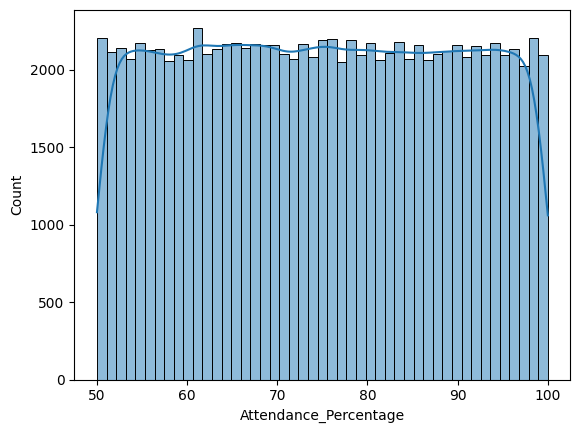

In [ ]:
sns.histplot(df["Attendance_Percentage"],kde=True)
plt.show()

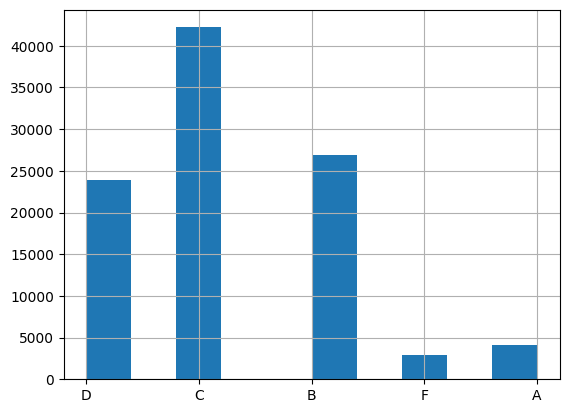

In [ ]:
df['Final_Grade'].hist()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Attendance_Percentage        100000 non-null  float64
 1   Internal_Assessment_Marks    100000 non-null  float64
 2   Previous_Semester_Grade      100000 non-null  object 
 3   Study_Hours_Per_Day          100000 non-null  float64
 4   Participation_In_Activities  100000 non-null  object 
 5   Family_Income_Level          100000 non-null  object 
 6   Parent_Education_Level       100000 non-null  object 
 7   Internet_Access              100000 non-null  object 
 8   Final_Grade                  100000 non-null  object 
dtypes: float64(3), object(6)
memory usage: 6.9+ MB


In [ ]:
df["Previous_Semester_Grade"].unique() #oc

array(['C', 'A', 'D', 'B', 'F'], dtype=object)

In [ ]:
df["Participation_In_Activities"].unique() #oc

array(['Low', 'High', 'Medium'], dtype=object)

In [ ]:
df["Family_Income_Level"].unique()#oc

array(['High', 'Middle', 'Low'], dtype=object)

In [ ]:
df["Parent_Education_Level"].unique()#oc

array(['School', 'Undergraduate', 'Postgraduate'], dtype=object)

In [ ]:
df["Internet_Access"].unique()#nc

array(['Yes', 'No'], dtype=object)

In [ ]:
df["Final_Grade"].unique()#oc

array(['D', 'C', 'B', 'F', 'A'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Internet_Access"]=le.fit_transform(df["Internet_Access"])

In [ ]:
df["Final_Grade"].replace(['D', 'C', 'B', 'F', 'A'],[3,2,1,4,0],inplace=True)

/tmp/ipykernel_6005/1906712993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Final_Grade"].replace(['D', 'C', 'B', 'F', 'A'],[3,2,1,4,0],inplace=True)
/tmp/ipykernel_6005/1906712993.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Final_Grade"].replace(['D', 'C', 'B', 'F', 'A'],[3,2

In [ ]:
df["Parent_Education_Level"].replace(['School', 'Undergraduate', 'Postgraduate'],[0,1,2],inplace=True)

/tmp/ipykernel_6005/1696435451.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Parent_Education_Level"].replace(['School', 'Undergraduate', 'Postgraduate'],[0,1,2],inplace=True)
/tmp/ipykernel_6005/1696435451.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Parent_Education_Level"].re

In [ ]:
df["Family_Income_Level"].replace(['High', 'Middle', 'Low'],[2,1,0],inplace=True)

/tmp/ipykernel_6005/3864104293.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Family_Income_Level"].replace(['High', 'Middle', 'Low'],[2,1,0],inplace=True)
/tmp/ipykernel_6005/3864104293.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Family_Income_Level"].replace(['High', 'Middle',

In [ ]:
df["Participation_In_Activities"].replace(['Low', 'High', 'Medium'],[0,2,1],inplace=True)

/tmp/ipykernel_6005/721637198.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Participation_In_Activities"].replace(['Low', 'High', 'Medium'],[0,2,1],inplace=True)
/tmp/ipykernel_6005/721637198.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Participation_In_Activities"].replace(['Lo

In [ ]:
df["Previous_Semester_Grade"].replace(['C', 'A', 'D', 'B', 'F'],[2,0,3,1,4],inplace=True)

/tmp/ipykernel_6005/2446016832.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Previous_Semester_Grade"].replace(['C', 'A', 'D', 'B', 'F'],[2,0,3,1,4],inplace=True)
/tmp/ipykernel_6005/2446016832.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Previous_Semester_Grade"].replace(['C', 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Attendance_Percentage        100000 non-null  float64
 1   Internal_Assessment_Marks    100000 non-null  float64
 2   Previous_Semester_Grade      100000 non-null  int64  
 3   Study_Hours_Per_Day          100000 non-null  float64
 4   Participation_In_Activities  100000 non-null  int64  
 5   Family_Income_Level          100000 non-null  int64  
 6   Parent_Education_Level       100000 non-null  int64  
 7   Internet_Access              100000 non-null  int64  
 8   Final_Grade                  100000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 6.9 MB


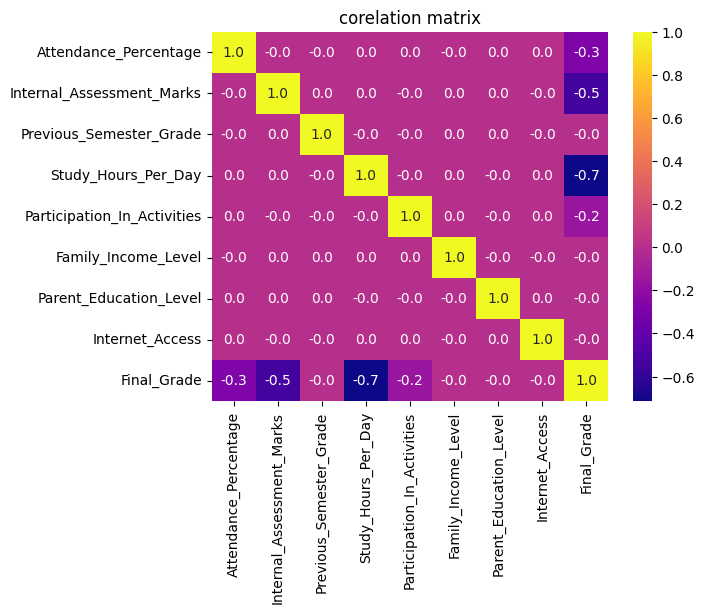

In [ ]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,cmap="plasma",annot=True,fmt="0.01f")
plt.title("corelation matrix")
plt.show()

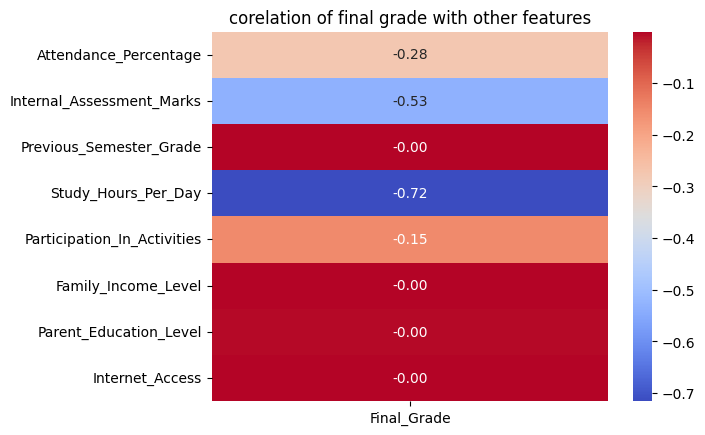

In [ ]:
p_corr=df.corr()['Final_Grade']
p_corr=p_corr.drop("Final_Grade")
sns.heatmap(p_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title("corelation of final grade with other features")
plt.show()

In [ ]:
df.drop(["Internet_Access","Parent_Education_Level","Family_Income_Level","Previous_Semester_Grade"],axis=1,inplace=True)

In [ ]:
df

,Attendance_Percentage,Internal_Assessment_Marks,Study_Hours_Per_Day,Participation_In_Activities,Final_Grade
0,81.97,31.75,3.7,0,3
1,79.52,32.22,3.4,2,3
2,85.80,79.09,3.4,2,2
3,84.91,53.82,3.4,1,3
4,54.84,89.32,3.9,0,2
...,...,...,...,...,...
99995,52.24,99.44,4.2,2,2
99996,96.92,32.75,7.2,0,2
99997,72.64,75.25,6.8,0,2
99998,55.50,69.64,4.0,1,3


<Axes: >

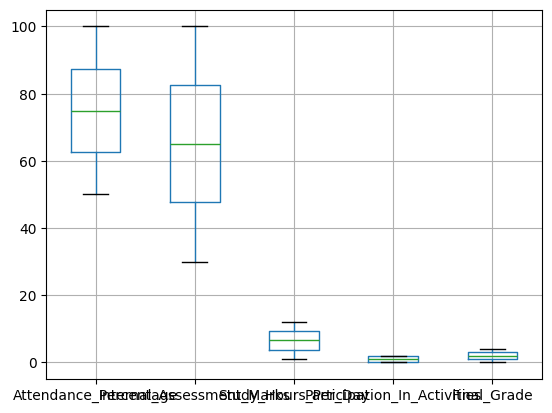

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:
        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df
df_cleaned = remove_outliers_iqr(df, exclude_column='Final_Grade')
df=df_cleaned

In [ ]:
from sklearn.preprocessing import MinMaxScaler
features=["Attendance_Percentage",	"Internal_Assessment_Marks",	"Study_Hours_Per_Day",	"Participation_In_Activities"]
scaler =MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"LogisticRegression  accuracy:{accuracy:.2f}")

LogisticRegression  accuracy:0.50


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = RandomForestClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"RandomForestClassifier  accuracy:{accuracy:.2f}")

RandomForestClassifier  accuracy:0.97


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"DecisionTreeClassifier  accuracy:{accuracy:.2f}")

DecisionTreeClassifier  accuracy:0.95


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = LinearSVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"LinearSVC  accuracy:{accuracy:.2f}")

LinearSVC  accuracy:0.92


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = XGBClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"XGBClassifier  accuracy:{accuracy:.2f}")

XGBClassifier  accuracy:0.98


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
model = AdaBoostClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"AdaBoostClassifier  accuracy:{accuracy:.2f}")

AdaBoostClassifier  accuracy:0.66


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
x  = df.drop("Final_Grade",axis=1)
y = df["Final_Grade"]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_x_train = x_train
        best_y_train = y_train
        best_x_test = x_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.5105


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Accuracy: 0.5076


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 Accuracy: 0.5062


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 Accuracy: 0.5067
Fold 5 Accuracy: 0.5105

 Best Fold: 1 with Accuracy: 0.5105


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5105

In [ ]:
model = DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.95165

In [ ]:
model = RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9729

In [ ]:
model = LinearSVC()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9117

In [ ]:
model = XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.9785

In [ ]:
model = AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.72855

# **DL**




In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
model = Sequential()
model.add(Dense(256, input_dim=4, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32,activation="relu"))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])

In [ ]:
model.fit(x_train,y_train,epochs=20,batch_size=42)

Epoch 1/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.2694 - loss: -95127232512.0000
Epoch 2/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.2696 - loss: -3617044561920.0000
Epoch 3/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.2696 - loss: -24149351202816.0000
Epoch 4/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2696 - loss: -84751775956992.0000
Epoch 5/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2696 - loss: -217821782999040.0000
Epoch 6/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2696 - loss: -465690788102144.0000
Epoch 7/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2696 - loss: -881669678563328.0000
Epoch 8/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2696 - loss: -1533576726183936.0000
Epoch 9/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2696 - loss: -2501053945741312.0000
Epoch 10/20
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2696 -

# **CONCLUSION**
This project focused on predicting student performance using various machine learning techniques. The dataset first underwent an extensive Exploratory Data Analysis (EDA) process, which included data cleaning, feature scaling, and outlier removal to improve data quality and model performance. These preprocessing steps helped ensure that the dataset was suitable for accurate and reliable prediction.

Multiple machine learning algorithms were implemented and compared, including Logistic Regression, Decision Tree Classifier, Random Forest Classifier, Linear SVC, XGBoost Classifier, and AdaBoost Classifier. The models were evaluated using both Train-Test Split validation and K-Fold Cross Validation to measure their performance and generalization capability across different subsets of the dataset.

Among all the models tested, the XGBoost Classifier achieved the highest accuracy in both Train-Test Split evaluation and K-Fold Cross Validation. This demonstrates the effectiveness of XGBoost in handling complex relationships within the student performance dataset and producing highly accurate predictions.

Overall, the project highlights the importance of proper data preprocessing, feature preparation, and model evaluation in building effective predictive systems. The results show that machine learning can be successfully used to predict student academic performance, which can help educators and institutions identify students who may need additional academic support and improve educational decision-making.